In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
import pickle

2026-03-11 17:33:13.228770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773250393.637963      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773250393.740770      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773250394.646820      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773250394.646877      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773250394.646882      17 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path="/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages"

cat_path=os.path.join(dataset_path,"Cat")
dog_path=os.path.join(dataset_path,"Dog")

In [3]:
IMG_SIZE=128

data=[]
labels=[]

for file in os.listdir(cat_path):
    try:
        img_path=os.path.join(cat_path,file)
        img=cv2.imread(img_path)
        if img is None:
            continue
        # img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(0)
    except:
        pass

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


In [4]:
IMG_SIZE=128

for file in os.listdir(dog_path):
    try:
        img_path=os.path.join(dog_path,file)
        img=cv2.imread(img_path)
        if img is None:
            continue
        # img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(1)
    except:
        pass

Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 399 extraneous bytes before marker 0xd9


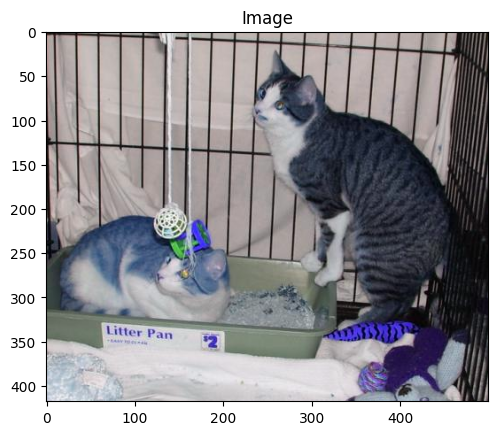

In [5]:
plt.imshow(data[0])
plt.title("Image")
plt.show()

In [6]:
print(data[0].shape)

(418, 500, 3)


In [7]:
print(data[0])

[[[130 116 110]
  [143 133 126]
  [152 146 139]
  ...
  [ 45  39  34]
  [ 21  15  10]
  [ 36  30  25]]

 [[ 88  69  64]
  [ 97  83  77]
  [102  94  87]
  ...
  [ 38  32  27]
  [ 18  12   7]
  [ 35  29  24]]

 [[ 41  16  12]
  [ 46  26  21]
  [ 44  30  24]
  ...
  [ 36  30  23]
  [ 23  17  10]
  [ 44  38  31]]

 ...

 [[187 194 209]
  [190 197 212]
  [192 197 212]
  ...
  [116 105 108]
  [ 93  79  85]
  [ 45  31  37]]

 [[196 197 211]
  [199 200 214]
  [204 205 219]
  ...
  [114 100 106]
  [ 75  61  67]
  [ 54  40  46]]

 [[192 192 206]
  [194 194 208]
  [199 199 213]
  ...
  [112  98 104]
  [ 73  59  65]
  [ 52  38  44]]]


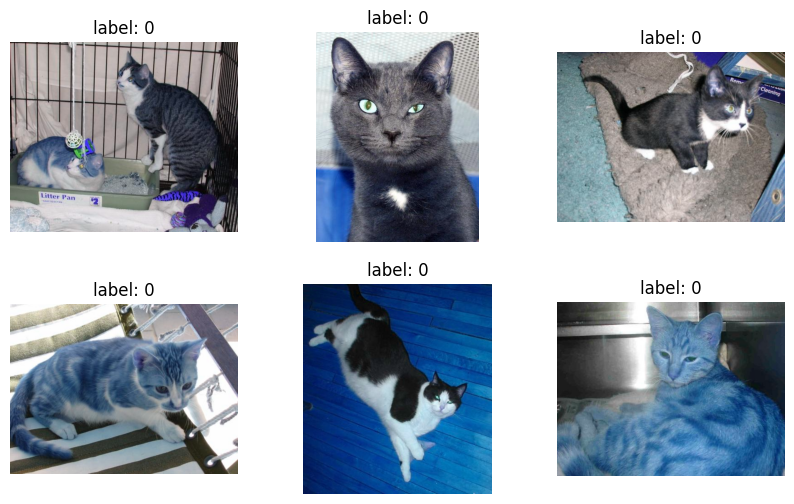

In [8]:
plt.figure(figsize = (10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(data[i])
    plt.title("label: " + str(labels[i]))
    plt.axis("off")

plt.show()

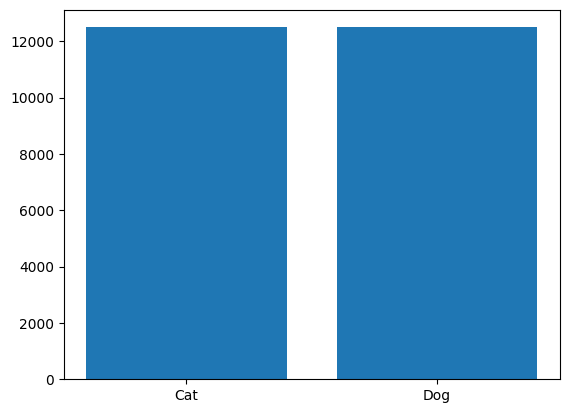

In [9]:
unique, counts=np.unique(labels,return_counts=True)

plt.bar(["Cat","Dog"],counts)
plt.show()

Text(0.5, 1.0, 'Original Image')

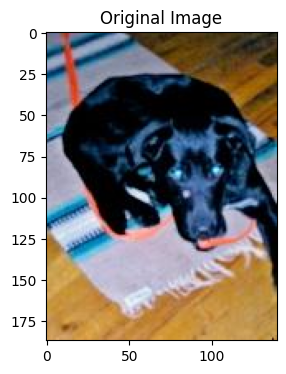

In [10]:
img = cv2.imread(img_path)

plt.figure(figsize = (8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

In [11]:
# NOW PERFORMING IMAGE RESIZING:

In [12]:
IMG_SIZE=128

data=[]
labels=[]

for file in os.listdir(cat_path):
    try:
        img_path=os.path.join(cat_path,file)
        img=cv2.imread(img_path)
        if img is None:
            continue
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(0)
    except:
        pass

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


In [13]:
IMG_SIZE=128

for file in os.listdir(dog_path):
    try:
        img_path=os.path.join(dog_path,file)
        img=cv2.imread(img_path)
        if img is None:
            continue
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(1)
    except:
        pass

Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 399 extraneous bytes before marker 0xd9


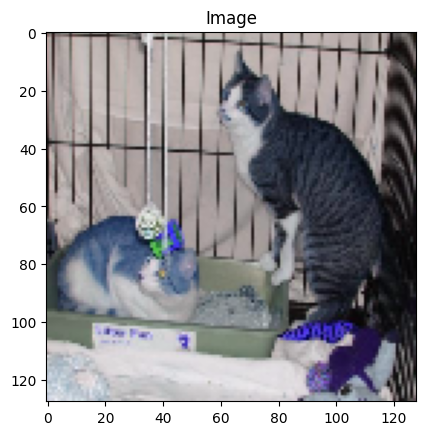

In [14]:
plt.imshow(data[0])
plt.title("Image")
plt.show()

In [15]:
print(data[0].shape)

(128, 128, 3)


In [16]:
print(data[0])

[[[ 92  80  73]
  [ 89  95  89]
  [ 30  27  24]
  ...
  [ 73  68  65]
  [ 35  31  28]
  [ 27  21  16]]

 [[137 107 104]
  [143 131 127]
  [ 53  32  32]
  ...
  [104  99  96]
  [ 56  51  48]
  [ 25  20  11]]

 [[188 162 157]
  [175 167 163]
  [ 46  29  28]
  ...
  [121 117 114]
  [ 75  70  67]
  [ 30  25  15]]

 ...

 [[184 193 204]
  [195 203 213]
  [202 208 218]
  ...
  [126 123 123]
  [ 23  18  17]
  [147 138 139]]

 [[200 208 223]
  [214 221 233]
  [221 225 234]
  ...
  [105 102 101]
  [ 38  34  31]
  [121 108 111]]

 [[200 201 216]
  [214 216 229]
  [211 212 222]
  ...
  [ 84  77  76]
  [ 85  84  82]
  [ 94  80  86]]]


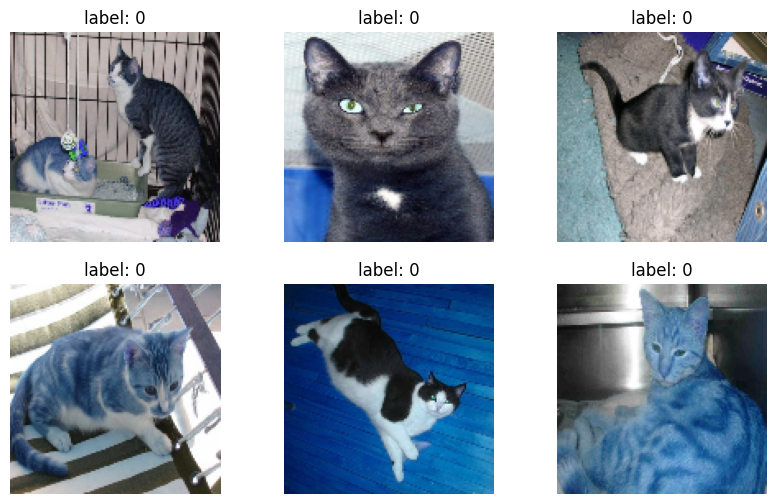

In [17]:
plt.figure(figsize = (10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(data[i])
    plt.title("label: " + str(labels[i]))
    plt.axis("off")

plt.show()

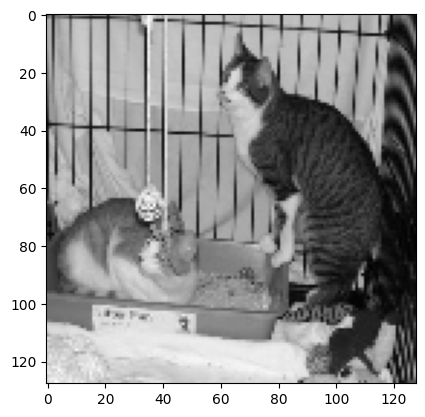

In [18]:
gray = cv2.cvtColor(data[0], cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap = "gray")
plt.show()